In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [11]:
titanic=sns.load_dataset("titanic")

features=["pclass","sex","fare","embarked","age"]
target=["survived"]

imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

X=titanic[features]
y=titanic["survived"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42
)

In [12]:
model=DecisionTreeClassifier()

model.fit(X_train,y_train)

y_pred_test=model.predict(X_test)
y_pred_train=model.predict(X_train)

print("Training accuracy:",accuracy_score(y_train,y_pred_train)*100,"%")
print("Testing accuracy:",accuracy_score(y_test,y_pred_test)*100,"%")

Training accuracy: 97.91332263242376 %
Testing accuracy: 77.98507462686567 %


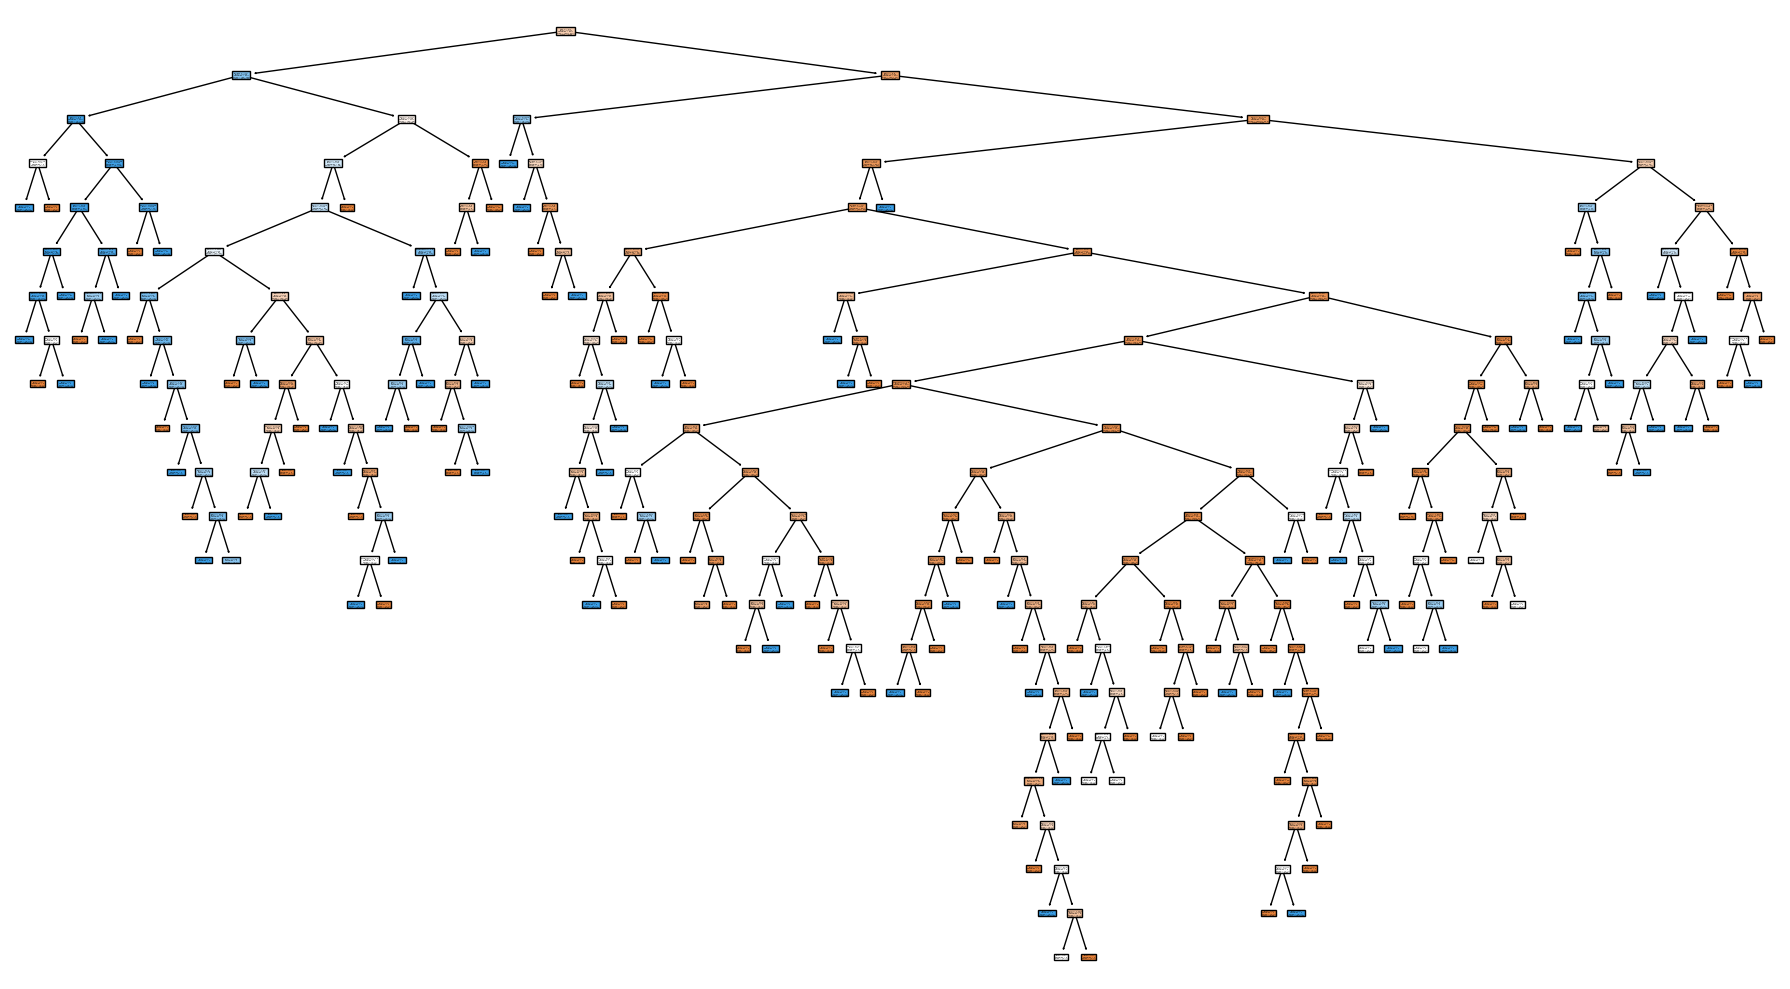

In [13]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()


In [20]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    max_depth=4
)

rf.fit(X_train,y_train)

y_pred=rf.predict(X_test)

print("OOB score:",rf.oob_score_*100,"%")
print("testing accuracy:",accuracy_score(y_test,y_pred)*100,"%")

OOB score: 81.54093097913324 %
testing accuracy: 82.08955223880598 %


In [24]:
#Bagging Classifier
from sklearn.ensemble import BaggingClassifier

base_model=DecisionTreeClassifier()

bagging=BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train,y_train)

y_pred=bagging.predict(X_test)

print("testing accuracy:",accuracy_score(y_test,y_pred)*100,"%")

testing accuracy: 77.98507462686567 %


In [26]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

base_model=LogisticRegression(max_iter=1000)

bagging=BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train,y_train)

y_pred=bagging.predict(X_test)

print("testing accuracy:",accuracy_score(y_test,y_pred)*100,"%")

testing accuracy: 79.47761194029852 %
